# CodeAlpha Internship - Task 2

## Exploratory Data Analysis of Retail Sales Data

### 1. Introduction

Exploratory Data Analysis (EDA) is the process of understanding and analyzing a dataset before performing further analysis. In this project, Python will be used to explore retail sales data, identify important patterns and trends, detect data quality issues and generate meaningful business insights.

## 2. Project Objective

The main objective of this project is to perform Exploratory Data Analysis on retail sales data.

The analysis will focus on:

- Understanding the structure of the dataset.
- Understanding the variables and their data types.
- Checking for missing values and duplicate records.
- Performing basic statistical analysis.
- Identifying trends and patterns.
- Detecting unusual values or anomalies.
- Creating visualizations to understand the data.
- Generating meaningful business insights from the dataset.

## 3. Business Questions

The following questions will guide the exploratory analysis:

1. Which product category generates the highest sales?
2. Which products are sold most frequently?
3. Which month has the highest sales?
4. Which region generates the highest revenue?
5. What is the average sales value?
6. Are there any unusual or extreme sales values?
7. Are there any missing values or duplicate records in the dataset?

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import zipfile
import os

with zipfile.ZipFile("online+retail.zip", "r") as zip_ref:
    zip_ref.extractall("online_retail")

os.listdir("online_retail")

['Online Retail.xlsx']

In [23]:
import pandas as pd

# Load the Excel file
file_path = "online_retail/Online Retail.xlsx"
df = pd.read_excel(file_path)

# View the first few rows and column names
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
# 1. Create a Total Sales column (Quantity * UnitPrice)
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Answer 5: Average Sales Value
print("=== Question 5 ===")
print("Average Sales Value:", df['TotalSales'].mean())

# Answer 6: Extreme / Unusual Values
print("\n=== Question 6 ===")
print(df[['Quantity', 'UnitPrice', 'TotalSales']].describe())

# Answer 7: Missing values and duplicates
print("\n=== Question 7 ===")
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicate records:", df.duplicated().sum())

=== Question 5 ===
Average Sales Value: 17.98779487699964

=== Question 6 ===
            Quantity      UnitPrice     TotalSales
count  541909.000000  541909.000000  541909.000000
mean        9.552250       4.611114      17.987795
std       218.081158      96.759853     378.810824
min    -80995.000000  -11062.060000 -168469.600000
25%         1.000000       1.250000       3.400000
50%         3.000000       2.080000       9.750000
75%        10.000000       4.130000      17.400000
max     80995.000000   38970.000000  168469.600000

=== Question 7 ===
Missing values per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalSales          0
dtype: int64

Total duplicate records: 5268


In [25]:
# 1. Remove duplicate rows
df_clean = df.drop_duplicates()

# 2. Filter out negative or zero quantities and unit prices (returns/cancellations)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 3. Check clean dataset shape
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

# 4. Recalculate average sales on clean data
print("New Average Sales Value:", df_clean['TotalSales'].mean())

Original shape: (541909, 9)
Cleaned shape: (524878, 9)
New Average Sales Value: 20.27539886221179


/tmp/ipykernel_2660/1795393492.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
/tmp/ipykernel_2660/1795393492.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r')


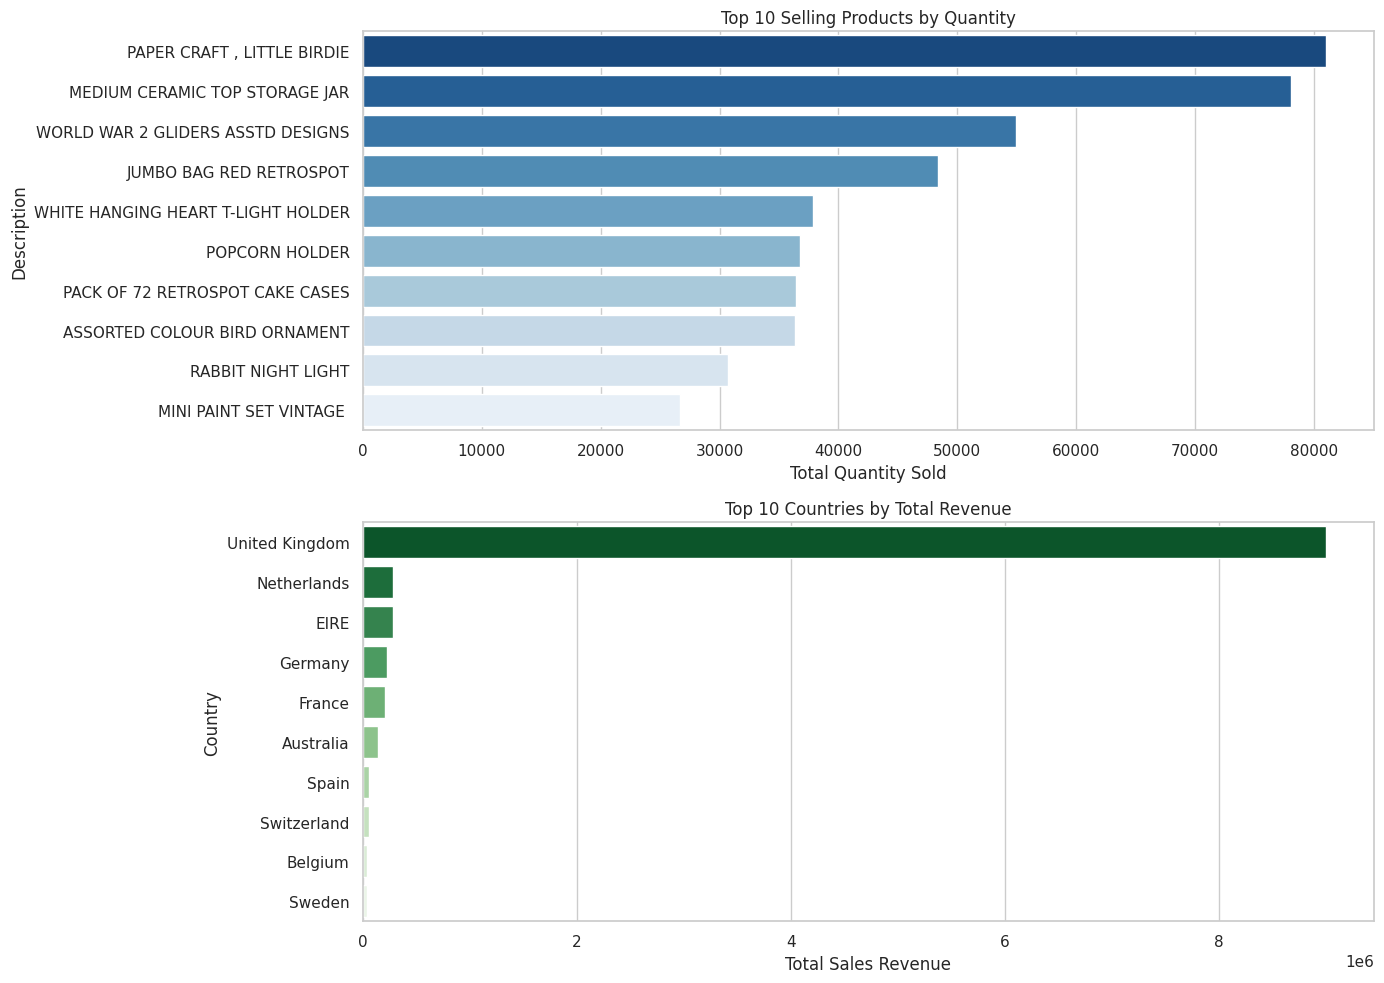

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# 1. Top 10 Best Selling Products by Quantity
plt.subplot(2, 1, 1)
top_products = df_clean.groupby('Description')['Quantity'].sum().nlargest(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')

# 2. Top 10 Countries by Total Revenue (excluding UK if needed, or total)
plt.subplot(2, 1, 2)
top_countries = df_clean.groupby('Country')['TotalSales'].sum().nlargest(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Sales Revenue')

plt.tight_layout()
plt.show()

In [27]:
# Save cleaned data to CSV
df_clean.to_csv("online_retail_cleaned.csv", index=False)
print("Cleaned dataset successfully saved as 'online_retail_cleaned.csv'!")

Cleaned dataset successfully saved as 'online_retail_cleaned.csv'!
